# Final project: Sparse vs Dense Activity (Intrinsic Plasticity)
In this project, we investigated how the target firing rate of an intrinsic plasticity rule shapes the dynamics and performance of a Spiking Neural Network (SNN). We compared networks with different target firing rates on a simple MNIST classification task.

## Preparation
We use the `snntorch` framework for our SNN. <br>
The following code cells install and import all relevant packages.

In [1]:
# Install the frameworks if they're not already available (safe to re-run).
!pip install snntorch --quiet

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF
# from snntorch import spikeplot as splt
from snntorch import utils

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    confusion_matrix,
)

To check whether our results reflect the general behavior (generalizability), we conducted the same experiments under three different seeds: 42, 36, and 12.

In [3]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

We trained the SNN using cpu.

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", device)

Using device: cuda


## Data loading
We use the MNIST dataset, which consists of 28x28 pixel grayscale images. <br>

Across all experiments, we used a batch size of 128 images. Hence, there were 469 training batches, and 79 test batches.

In [5]:
# dataloader arguments
batch_size = 128
data_path = "/tmp/data/mnist"

# scale pixel intensities to [0, 1].
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,)),
])

mnist_train = datasets.MNIST(data_path, train=True,  download=True, transform=transform)
mnist_test  = datasets.MNIST(data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True,  drop_last=True)
test_loader  = DataLoader(mnist_test,  batch_size=batch_size, shuffle=True,  drop_last=True)

print("Train samples:", len(mnist_train), "| Test samples:", len(mnist_test))

Train samples: 60000 | Test samples: 10000


## Main code


### Encoding
In the blockseminar, we were introduced to three options for encoding the image input in a biologically-inspired manner:

*   ***firing rate***: <br>
= we consider the firing rate of neurons <br>
--> use **rate encoding**: pixel intensities translate into a firing rate (high intensity = frequent spikes) <br>
--> the predicted class is determined based on **the output neuron that has highest spike count** <br>
--> in case of a smaller firing threshold, the **neuron would fire more frequently**

*   ***relative spike timing***: <br>
= we consider the firing time of neurons <br>
--> use **time-to-first spike encoding (TTFS)**: each neuron fires exactly once & pixel intensities are inversely proportional to their firing time (high intensity = early spike) <br>
--> the predicted class is determined based on **the output neuron that fires most quickly** <br>
--> in case of a smaller firing threshold, the **neuron would fire earlier**

*   ***rank order***: <br>
= we only care about the spike order of neurons, not their exact firing time <br>
--> use **rank order encoding**: each neuron fires exactly once & more intense pixels fire earlier <br>
--> the predicted class is determined based on **the output neuron that fires first** <br>
--> in case of a smaller firing threshold, the **neuron would fire earlier**

In our project, we use **rate-coded spikes**. <br>

An intuitive implementation of rate encoding is given in our custom function `encode_rate`. Each raw pixel intensity between [0, 255] is mapped to a firing rate. A black pixel (value 0) corresponds to a firing rate of 0 Hz. A white pixel (value 255) corresponds to a firing rate of 50 Hz. Each timestep, we draw a spike with a probability proportional to that rate (Bernoulli sampling). Brighter pixels fire more often over the T=400 timesteps.

In [6]:
# Custom implementation of rate encoding (NOT USED IN OUR PROJECT, ONLY SHOWN FOR INTUITION!)

def encode_rate(
    x,
    rmin:int=0,   # HZ for black pixel
    rmax:int=50,  # Hz for white pixel
    T:int=400,    # number of timesteps (identical to num_steps in snntorch.spikegen)
):
    """Convert raw pixel intensities into a rate-coded spike train.

    Higher intensity pixels produce a higher firing rate (more spikes).
    Returns a boolean tensor of shape [T, num_pixels].
    """
    x = torch.as_tensor(x, dtype=torch.float32)

    # Map intensity -> firing rate (in Hz), between rmin and rmax
    rates = rmin + (rmax - rmin) * x

    # Per-timestep spike probability (assuming a 1 ms bin -> divide Hz by 1000)
    p = torch.clamp(rates / 1000.0, min=0.0, max=1.0)

    # Bernoulli sampling: one draw per (timestep, pixel)
    spikes = torch.rand(T, x.numel()) < p.unsqueeze(0)
    return spikes

`snntorch` already provides a function for rate encoding (`snntorch.spikegen`), which maps normalized pixel intensities (i.e. pixel values are in [0, 1]) to firing rates. Since our data loaders automatically normalize the input images, we used this predefined function in our project.

### Leaky Integrate-and-Fire neuron (`snntorch.Leaky`)
The `Leaky()` neuron provided by snntorch library already provides many essential parameters (documentation: https://snntorch.readthedocs.io/en/latest/snn.neurons_leaky.html). <br>

Here is a description of the most relevant ones: <br>

---

The **resting membrane potential** is fixed to 0.0.

---

The **leak factor** of the membrane (beta) can be defined manually in the range [0,1], typically one chooses `beta=0.9`. A high beta refers to slow decay / long memory. A low beta refers to fast decay / short memory. It can be made learnable with `learn_beta=True`.

---

The **firing threshold** can be defined manually, typically one chooses `threshold=1.0`. It can be made learnable with `learn_threshold=True`.

---

For a **hard reset** use `reset_mechanism = “zero” `, which sets the membrane potential to 0.0 after a spike. <br>
For a **soft reset** use `reset_mechanism="subtract"`, which subtracts the firing threshold from the current membrane potential after a spike.

---

You can train the neuron via backpropagation. `spike_grad` is the **surrogate gradient function** used during backpropagation. By default it is `None`, i.e. the default is used. <br>
Examples for surrogate gradient functions are:
- `snntorch.surrogate.fast_sigmoid()`
- `snntorch.surrogate.atan()`
- `snntorch.surrogate.sigmoid()`

Surrogate gradients can also be **disabled** with `surrogate_disable=True` (per default, it is False). This makes the neuron non-trainable with gradient descent.

### Leaky Integrate-and-Fire neuron with intrinsic plasticity
The official `snntorch.Leaky()` does not allow for intrinsic plasticity. Hence, we extended the forward function to allow updating the firing threshold based on the firing rate.

- With `self.rate = spk.float().mean(dim=0)` we can compute the firing rate individually for each neuron in the layer. We average only over all batch input samples. Hence, the firing threshold can differ between neurons of a layer. **[This is what we applied in our project.]**

- With `self.rate = spk.float().mean()` we average the firing rate over all batch input samples and neurons. Hence, the firing threshold is identical for all neurons in the layer.

NOTE: Currently, we only consider the current firing rate, which can differ drastically between steps. We could also consider the previous firing rate for smoother transitions, e.g. the exponential moving average `self.rate = 0.99 * self.rate + 0.01 * spk.float().mean()`.

In [7]:
class LeakyHIP(snn.Leaky):
    def __init__(self, *args, eta=0.02, target_rate=0.2, **kwargs):
        super().__init__(*args, **kwargs)
        self.eta = eta
        self.target_rate = target_rate
        self.register_buffer("rate", torch.zeros(1))

    def forward(self, input_, mem=None):
        out = super().forward(input_, mem)

        # If init_hidden = True, only spk is returned
        if isinstance(out, torch.Tensor):
          spk = out        # whether a spike happened
          mem = self.mem   # internal membrane state
        # If both spk and mem are returned
        else:
          spk, mem = out

        if self.training:
          # compute the average (across samples) firing rate of each neuron in the layer
          self.rate = spk.float().mean(dim=0)
          # homeostatic intrinsic plasticity update
          with torch.no_grad():
            self.threshold = self.threshold + self.eta * (self.rate - self.target_rate)
            self.threshold = torch.clamp(self.threshold, 0.05, 5.0)

        if self.output:
            return spk, mem
        elif self.init_hidden:
            return spk
        else:
            return spk, mem

### Learning rule
We use **surrogate gradient descent**, whick keeps the Heaviside step function as activation function during the forward pass (true spike), but substitutes it with a smooth surrogate during backpropagation to make it differentiable.

In [8]:
def surrogate_derivative(spike_grad, x):
    """Return d(spike)/dx of a snnTorch surrogate, evaluated on tensor x.

    x is the membrane 'overdrive' U_OD = U - U_thr.
    """
    x = x.detach().clone().requires_grad_(True)
    out = spike_grad(x)          # Heaviside on the forward pass
    out.sum().backward()         # surrogate on the backward pass
    return x.grad

### SNN architecture
We constructed a 3-layer SNN architecture:
- **input layer [784 neurons]**: 1 neuron per img pixel (MNIST images are 28x28 pixels)
- **hidden layer [1000 neurons]**
- **output layer [10 neurons]**: 1 neuron per MNIST class

To investigate how typical model performance and dynamics compares to when applying intrinsic plasticity, we allow the use of either (a) the "normal" LIF neurons `snn.Leaky` (provided by `snntorch`), or (b) our extended version `LeakyHIP` which allows threshold adaptation.

In [9]:
def build_snn(
    HIP:bool=False,
    etas:list=[0.03, 0.03],
    target_rates:list=[0.05, 0.05],
    num_inputs:int=784,
    num_hidden:int=1000,
    num_outputs:int=10,
    beta:float=0.9,
    spike_grad:snn.surrogate=surrogate.fast_sigmoid(slope=25),
    device:torch.device=None,
):
  """Build the Spiking Neural Network architecture."""
  if HIP:
    if target_rates[1] is not None:
      # Experiment setting 1: uniform HIP in both hidden and output layer
      net = nn.Sequential(
          nn.Linear(num_inputs, num_hidden),
          LeakyHIP(beta=beta, init_hidden=True, spike_grad=spike_grad, eta=etas[0], target_rate=target_rates[0]),
          nn.Linear(num_hidden, num_outputs),
          LeakyHIP(beta=beta, init_hidden=True, spike_grad=spike_grad, eta=etas[1], target_rate=target_rates[1], output=True),
      ).to(device)
    else:
      # Experiment setting 2: uniform HIP in hidden layer only
      net = nn.Sequential(
          nn.Linear(num_inputs, num_hidden),
          LeakyHIP(beta=beta, init_hidden=True, spike_grad=spike_grad, eta=etas[0], target_rate=target_rates[0]),
          nn.Linear(num_hidden, num_outputs),
          snn.Leaky(beta=beta, init_hidden=True, spike_grad=spike_grad, output=True),
      ).to(device)

  else:
    # Baseline: no HIP
    net = nn.Sequential(
        nn.Linear(num_inputs, num_hidden),
        snn.Leaky(beta=beta, init_hidden=True, spike_grad=spike_grad),
        nn.Linear(num_hidden, num_outputs),
        snn.Leaky(beta=beta, init_hidden=True, spike_grad=spike_grad, output=True),
    ).to(device)

  return net

### SNN training

The thresholds (`t_hidden_history`, `t_output_history`) and spikes (`spk_rec_output`, `spk_rec_hidden`) are logged inside the `forward_pass` function. The recordings capture how thresholds evolve during temporal processing of an input, as well as the spike timing patterns across the (in our case) 25 timesteps. We use those recordings at inference time to **analyze the *trained* model's spiking behavior / temporal spiking patterns on test samples**.

In [10]:
def forward_pass(net, spike_data):
    """Run the network over time on a pre-encoded spike train.

    spike_data: [num_steps, batch, 1, 28, 28] (from spikegen.rate)
    Returns stacked hidden and stacked output spikes (binary tensor): [num_steps, batch_size, num_neurons_in layer]
    """
    spk_rec_output = []
    spk_rec_hidden = []
    t_hidden_history = []
    t_output_history = []
    utils.reset(net)                       # clear membrane states of every Leaky

    # Iterate over each time step
    for step in range(spike_data.size(0)):
        x_t = spike_data[step]
        x_t = x_t.view(x_t.size(0), -1)    # shape: [batch, 784]

        x_hidden = net[0](x_t)
        spk_hidden = net[1](x_hidden)
        spk_rec_hidden.append(spk_hidden)  # Save hidden

        x_out = net[2](spk_hidden)
        spk_out, _ = net[3](x_out)
        spk_rec_output.append(spk_out)     # Save output

        # Log thresholds of hidden layer neurons
        t_hidden_history.append(net[1].threshold.clone().detach().cpu())
        # Log thresholds of output layer neurons
        t_output_history.append(net[3].threshold.clone().detach().cpu())

    return torch.stack(spk_rec_output), torch.stack(spk_rec_hidden)


def batch_accuracy(loader, net, num_steps):
    """Accuracy over a whole DataLoader using a rate code (spike counts)."""
    net.eval()
    total, acc = 0, 0
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            spike_data = spikegen.rate(data, num_steps=num_steps)
            # Unpack the tuple, only output spikes are needed for accuracy
            spk_rec_output, _ = forward_pass(net, spike_data)
            # Use spk_rec_output for accuracy calculation
            acc   += SF.accuracy_rate(spk_rec_output, targets) * spk_rec_output.size(1)
            total += spk_rec_output.size(1)
    return acc / total

The thresholds (`threshold_log_hidden`, `threshold_log_output`) are also logged inside the `train_model` function. The recordings capture how the thresholds evolve across training batches / training steps. We use those recordings for **training-level analysis**:
- How are thresholds adapted during training?
- Are hidden/output layers adapting thresholds differently over training steps?
- Are individual neurons within a layer adapting thresholds differently?
- Are thresholds exploding (go towards clipped maximum) or vanishing (go towards clipped minimum)?

In [11]:
def train_model(net, train_loader, test_loader, num_epochs:int=1, num_steps:int=25, device:torch.device=None):
  """Train the SNN."""
  loss_fn   = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, betas=(0.9, 0.999))

  loss_hist, test_acc_hist = [], []
  threshold_log_hidden, threshold_log_output = [], []
  counter = 0

  for epoch in range(num_epochs):
      for data, targets in train_loader:
          data, targets = data.to(device), targets.to(device)

          # rate-encode the images into a spike train
          spike_data = spikegen.rate(data, num_steps=num_steps)

          # run the forward pass over time
          net.train()
          # Unpack the tuple returned by forward_pass
          spk_rec_output, spk_rec_hidden = forward_pass(net, spike_data)

          # log the resulting thresholds of Leaky neurons
          threshold_log_hidden.append(net[1].threshold.detach().cpu().clone())
          threshold_log_output.append(net[3].threshold.detach().cpu().clone())

          # compute the loss on the output spikes
          # Use spk_rec_output for loss calculation
          out_spk_count = spk_rec_output.sum(dim=0)   # sum over time
          loss_val = loss_fn(out_spk_count, targets)

          # backward pass
          optimizer.zero_grad()
          loss_val.backward()
          optimizer.step()

          loss_hist.append(loss_val.item())

          # apply the current model state to test data every 50 epochs
          if counter % 50 == 0:
              test_acc = batch_accuracy(test_loader, net, num_steps)
              test_acc_hist.append(test_acc.item())
              print(f"Iteration {counter:4d} | loss {loss_val.item():.3f} "
                    f"| test acc {test_acc * 100:.2f}%")
          counter += 1

  return loss_hist, test_acc_hist, threshold_log_hidden, threshold_log_output

During experimentation phase of the project, we tried out different parameter settings, while keeping HIP-related parameters fixed (`etas = [0.03, 0.03]`, `target_rates = [0.05, 0.05]`). <br>
- hidden layer size (`num_steps`):  [1000, 1500, 2000]
- timesteps of the rate-coded input (`num_steps`): [25, 50, 75]
- slope of surrogate function defined in `spike_grad`: [5, 15, 25, 35]

We didn't notice significant differences in resulting model performance when varying the number of hidden neurons. Hence we sticked with 1,000 hidden neurons, which is a more simple model architecture. <br>

Increasing the number of timesteps of the rate-encoded input lead to worse model performance, but HIP-incorporated training does seem to suffer less. With `num_steps=75` we observed the only case, where the model trained with HIP performed significantly better than the model without HIP. We decided to use `num_steps=25` in our project, because it led to the best overall performance. Assuming a bin width of 1ms, this means each input image is shown 25ms. However, to explore differences between HIP-incorporated and baseline training, a higher step size might be more interesting. <br>

A lower slope in the surrogate function lead to better performance in both baseline and HIP-based models. This could be due to a lower slope allowing for smoother gradients, and hence more stable training. Hence, we decided to use `slope=5`.

In [12]:
# Final parameter setting that we decided on after experimentation phase
num_hidden = 1000                              # number of hidden neurons
spike_grad = surrogate.fast_sigmoid(slope=5)
num_steps = 25                                 # timesteps of the rate-coded input
num_epochs = 1                                 # number of epochs to train

In our final project experiments, we varied the target activity rates to investigate its influence on model performance and activity patterns. <br>

**Experiment setting 1: Influence of *uniform* target firing rate** <br>
We tested four different rates in the uniform configuration (i.e. same rate for hidden and output neurons):
*  `target_rates = [0.00, 0.00]`
*  `target_rates = [0.05, 0.05]`
*  `target_rates = [0.10, 0.10]`
*  `target_rates = [0.15, 0.15]`

**Experiment setting 2: Influence of target firing rate when *disabling intrinsity in the output layer*** <br>
We tested four different rates, while disabiling HIP for the output layer neurons:
*  `target_rates = [0.00, None]`
*  `target_rates = [0.05, None]`
*  `target_rates = [0.10, None]`
*  `target_rates = [0.15, None]`


In [13]:
HIP = True                                     # whether to apply threshold adaptation
etas = [0.03, 0.03]                            # [eta for hidden layer, eta for output layer]
target_rates = [0.05, 0.05]                    # [target rate for hidden layer, target rate for output layer]

In [14]:
# Create the SNN
net = build_snn(
    HIP=HIP,
    etas=etas,
    target_rates=target_rates,
    num_inputs=28 * 28,                           # number of MNIST image pixels
    num_hidden=num_hidden,
    num_outputs=10,                               # number of MNIST classes
    beta=0.9,                                     # membrane decay of the LIF neuron
    spike_grad=spike_grad,
    device=device,
)

In [15]:
# Train the SNN
loss_hist, test_acc_hist, threshold_log_hidden, threshold_log_output = train_model(
    net=net,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=num_epochs,
    num_steps=num_steps,
    device=device,
)


Iteration    0 | loss 2.338 | test acc 24.62%
Iteration   50 | loss 0.525 | test acc 92.39%
Iteration  100 | loss 0.257 | test acc 93.71%
Iteration  150 | loss 0.376 | test acc 94.19%
Iteration  200 | loss 0.194 | test acc 95.31%
Iteration  250 | loss 0.068 | test acc 96.14%
Iteration  300 | loss 0.294 | test acc 95.79%
Iteration  350 | loss 0.193 | test acc 95.96%
Iteration  400 | loss 0.106 | test acc 95.63%
Iteration  450 | loss 0.185 | test acc 95.84%


### Evaluation of training loss progression
We plot the training loss after processing each batch. <br>
Generally, we observed that the loss decreases until reaching a saturation point around 0.1.

Final test set accuracy: 96.09%


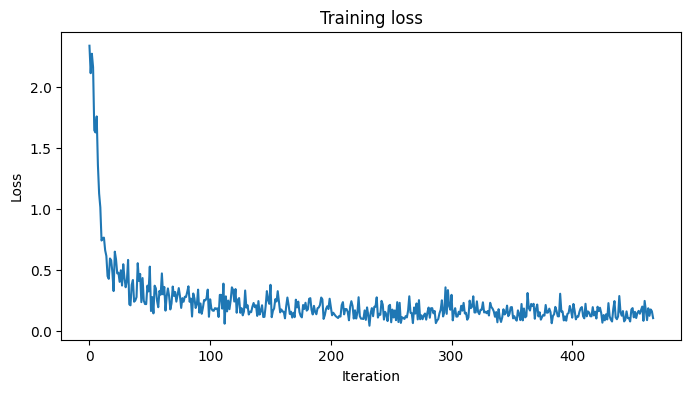

In [16]:
# Final test accuracy and a plot of the training loss
final_acc = batch_accuracy(test_loader, net, num_steps)
print(f"Final test set accuracy: {final_acc * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### Evaluation of threshold adaptation during training
We plot the threshold of ...
- 100 hidden neurons <br> --> the first 100 neurons in hidden layer <br> --> we need to sample because plotting all 1000 neurons makes plot non-interpretable
- all 10 output neurons

... over all 469 training steps (we train 1 epoch with 469 batches.)

<br>

Generally, we observed **clear differences in the threshold adaptation between hidden layer and output layer neurons**, which we **ground in their different function**. <br>

- The **thresholds of hidden neurons tend to vary more strongly over training**. Hidden neurons receive the raw encoded spikes and must transform them into useful representations. The individual neurons compete in terms of who extracts the most useful features. Hidden neurons fire much more frequently (high spike activity), leading to frequent and more violent threshold updates (strong adaptation pressure). <br>

- The **thresholds of output neurons evolve more linearly over training**. Output neurons do not extract features but only accumulate evidence for each class. This leads to: monotonic increases (if the neuron fires too often), monotonic decreases (if it fires too rarely), and stability (if firing rate is balanced). <br>
We hypothized whether **the threshold that each output neuron converges towards could indicate the model's class biases/preferences**, in the sense that an output neuron with higher resulting threshold could correspond to the model's tendency to preference that class (that output neuron generally receives a stronger input and counteracts this by increasing the threshold, in order to restrict firing).

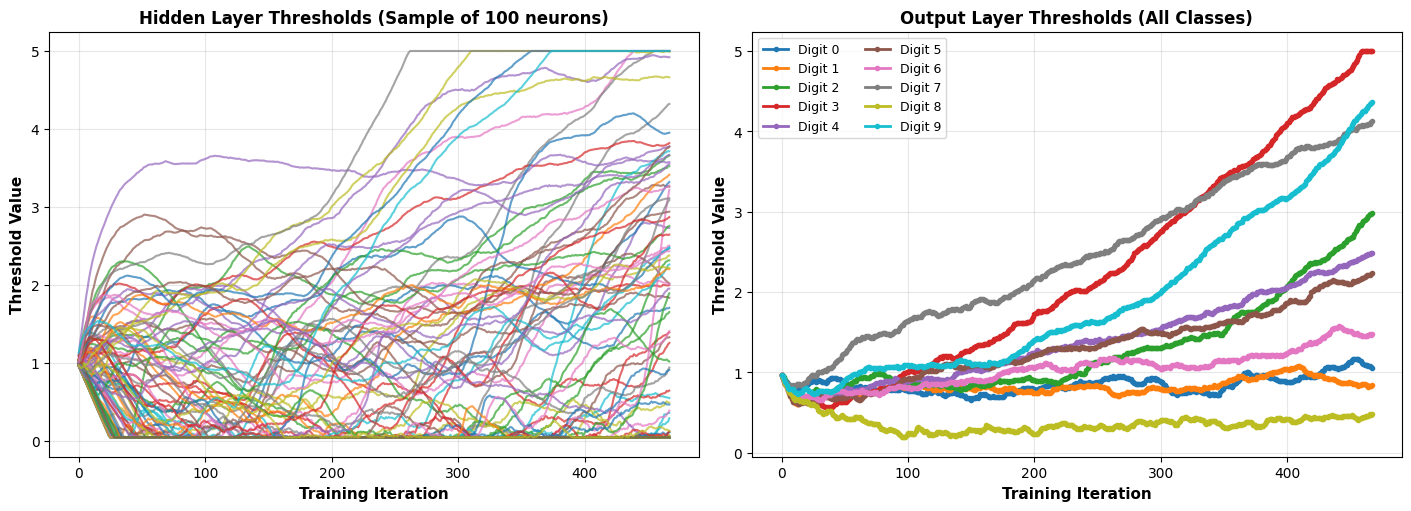

In [17]:
def plot_threshold_evolution_lines(threshold_log_hidden, threshold_log_output, name="Network", num_neurons_sample=10):
    """
    Alternative visualization: plot threshold changes as lines for selected neurons.
    """

    thresholds_h = torch.stack(threshold_log_hidden).numpy()
    thresholds_o = torch.stack(threshold_log_output).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    # Hidden layer - sample some neurons
    ax = axes[0]
    neurons_to_plot = min(num_neurons_sample, thresholds_h.shape[1])

    for i in range(neurons_to_plot):
        ax.plot(thresholds_h[:, i], alpha=0.7, linewidth=1.5)

    ax.set_xlabel('Training Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Threshold Value', fontsize=11, fontweight='bold')
    ax.set_title(f'Hidden Layer Thresholds (Sample of {neurons_to_plot} neurons)',
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Output layer - all 10 neurons
    ax = axes[1]

    for i in range(10):
        ax.plot(thresholds_o[:, i], label=f'Digit {i}', linewidth=2, marker='o', markersize=3)

    ax.set_xlabel('Training Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Threshold Value', fontsize=11, fontweight='bold')
    ax.set_title('Output Layer Thresholds (All Classes)',
                fontsize=12, fontweight='bold')
    ax.legend(loc='best', ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.show()

# Usage
plot_threshold_evolution_lines(threshold_log_hidden, threshold_log_output, num_neurons_sample=100)

We provide an alternative visualization (heatmap) which allows us to trace threshold progression during training a bit better, especially for the hidden neurons.

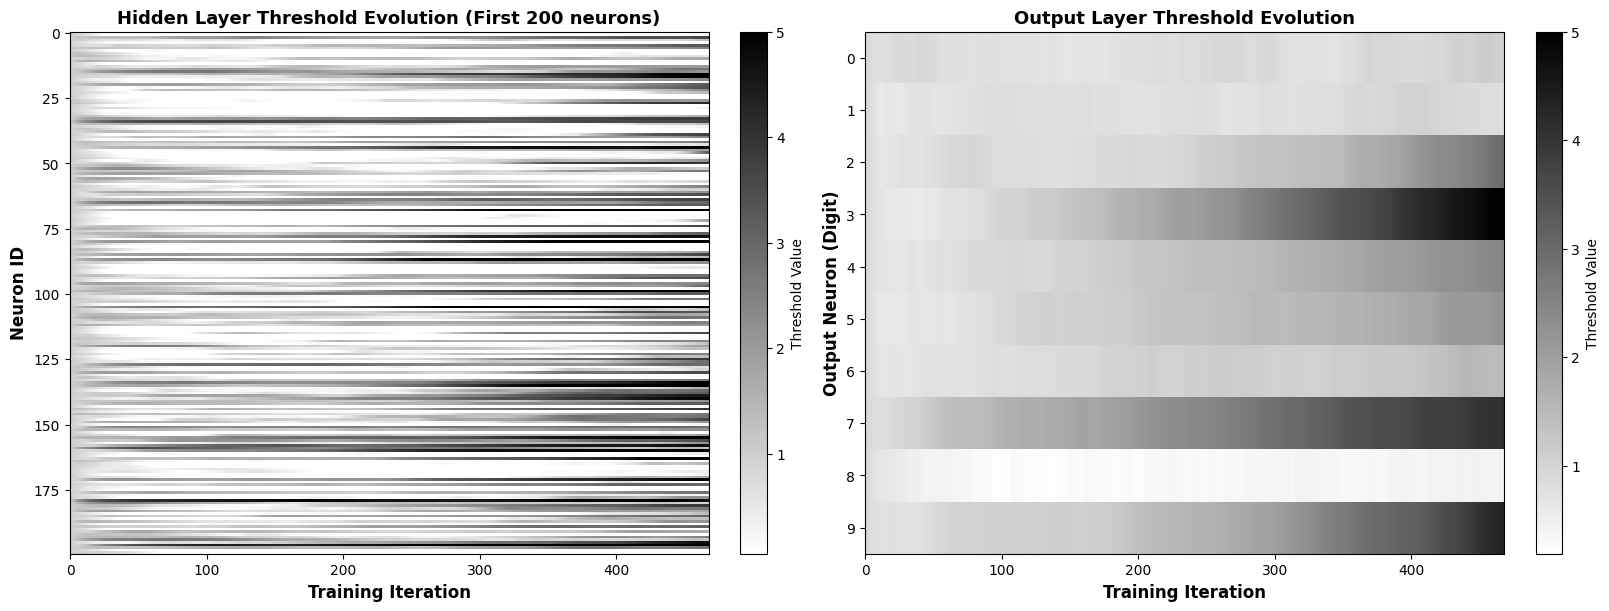


THRESHOLD EVOLUTION STATISTICS

HIDDEN LAYER (showing first 200 neurons):
  Initial thresholds: min=0.9625, max=1.1418, mean=0.9968
  Final thresholds:   min=0.0500, max=5.0000, mean=1.8411
  Total change:       min=-0.9125, max=3.8582, mean=0.8444

OUTPUT LAYER:
  Initial thresholds: min=0.9625, max=0.9677, mean=0.9631
  Final thresholds:   min=0.4802, max=5.0000, mean=2.5045
  Total change:       min=-0.4823, max=4.0323, mean=1.5415



In [18]:
def plot_threshold_evolution(threshold_log_hidden, threshold_log_output, name="Network", num_neurons_sample=10):
    """
    Visualize how neuron thresholds change over training iterations.
    Uses heatmap: white=low threshold (easy to fire), black=high threshold (hard to fire)

    threshold_log_hidden: list of tensors from train_model() [num_iterations, num_hidden]
    threshold_log_output: list of tensors from train_model() [num_iterations, num_outputs]
    """

    # Stack into single tensors: [iterations, neurons]
    thresholds_h = torch.stack(threshold_log_hidden).numpy()  # [iterations, num_hidden]
    thresholds_o = torch.stack(threshold_log_output).numpy()  # [iterations, num_outputs]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    # ============ HIDDEN LAYER THRESHOLDS ============
    ax = axes[0]

    # Show subset of neurons if there are too many
    num_neurons_show = min(num_neurons_sample, thresholds_h.shape[1])
    thresholds_h_subset = thresholds_h[:, :num_neurons_show]

    # Invert colormap: white=low, black=high (use 'gray_r' for reversed)
    im_h = ax.imshow(thresholds_h_subset.T, aspect='auto', cmap='gray_r', interpolation='nearest')

    ax.set_xlabel('Training Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Neuron ID', fontsize=12, fontweight='bold')
    ax.set_title(f'Hidden Layer Threshold Evolution (First {num_neurons_show} neurons)',
                fontsize=13, fontweight='bold')

    cbar_h = plt.colorbar(im_h, ax=ax, label='Threshold Value')

    # Add grid
    ax.grid(False)

    # ============ OUTPUT LAYER THRESHOLDS ============
    ax = axes[1]

    im_o = ax.imshow(thresholds_o.T, aspect='auto', cmap='gray_r', interpolation='nearest')

    ax.set_xlabel('Training Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Output Neuron (Digit)', fontsize=12, fontweight='bold')
    ax.set_title('Output Layer Threshold Evolution',
                fontsize=13, fontweight='bold')
    ax.set_yticks(range(10))

    cbar_o = plt.colorbar(im_o, ax=ax, label='Threshold Value')

    # Add grid
    ax.grid(False)

    plt.show()

    # === PRINT STATISTICS ===
    print("\n" + "="*70)
    print("THRESHOLD EVOLUTION STATISTICS")
    print("="*70)

    print(f"\nHIDDEN LAYER (showing first {num_neurons_show} neurons):")
    print(f"  Initial thresholds: min={thresholds_h_subset[0].min():.4f}, "
          f"max={thresholds_h_subset[0].max():.4f}, "
          f"mean={thresholds_h_subset[0].mean():.4f}")
    print(f"  Final thresholds:   min={thresholds_h_subset[-1].min():.4f}, "
          f"max={thresholds_h_subset[-1].max():.4f}, "
          f"mean={thresholds_h_subset[-1].mean():.4f}")
    print(f"  Total change:       min={thresholds_h_subset[-1].min() - thresholds_h_subset[0].min():.4f}, "
          f"max={thresholds_h_subset[-1].max() - thresholds_h_subset[0].max():.4f}, "
          f"mean={thresholds_h_subset[-1].mean() - thresholds_h_subset[0].mean():.4f}")

    print(f"\nOUTPUT LAYER:")
    print(f"  Initial thresholds: min={thresholds_o[0].min():.4f}, "
          f"max={thresholds_o[0].max():.4f}, "
          f"mean={thresholds_o[0].mean():.4f}")
    print(f"  Final thresholds:   min={thresholds_o[-1].min():.4f}, "
          f"max={thresholds_o[-1].max():.4f}, "
          f"mean={thresholds_o[-1].mean():.4f}")
    print(f"  Total change:       min={thresholds_o[-1].min() - thresholds_o[0].min():.4f}, "
          f"max={thresholds_o[-1].max() - thresholds_o[0].max():.4f}, "
          f"mean={thresholds_o[-1].mean() - thresholds_o[0].mean():.4f}")

    print("="*70 + "\n")

    return thresholds_h, thresholds_o


# Usage
thresholds_h, thresholds_o = plot_threshold_evolution(
    threshold_log_hidden,
    threshold_log_output,
    name=f"Network (HIP={HIP})",
    num_neurons_sample=200,
)

### Inference
We applied our trained model to our test data.

In [19]:
def test_model(net, test_loader, num_steps=25, device=None):
    """Test a trained model on the test set and collect all necessary data for evaluation.

    Returns:
      - all_output_spikes: the spike recordings for the output layer in shape (num_batches, num_steps, batch_size, num_neurons)
      - all_hidden_spikes: the spike recordings for the hidden layer in shape (num_batches, num_steps, batch_size, num_neurons)
      - all_targets: the labels in shape (num_batches, batch_size)
    """
    net.eval()

    all_output_spikes = []
    all_hidden_spikes = []
    all_targets = []

    print(f"\nTesting model on test set...")
    print("Processing batches...", end=" ")

    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(test_loader):
            data = data.to(device)

            # Encode to spikes
            spike_data = spikegen.rate(data, num_steps=num_steps)

            # Forward pass (returns both hidden and output spikes)
            spk_out, spk_hidden = forward_pass(net, spike_data)

            # Store spike data
            all_output_spikes.append(spk_out.cpu())
            all_hidden_spikes.append(spk_hidden.cpu())
            all_targets.append(targets)

            if (batch_idx + 1) % 10 == 0:
                print(f"{batch_idx + 1}...", end=" ")

    print("Done!")
    return all_output_spikes, all_hidden_spikes, all_targets

We computed raw spike data for test samples: <br>
- `output_spikes`, `hidden_spikes`: the spike trains in shape [num_test_samples, num_timesteps, num_neurons]
- `targets`: the class labels of test samples in shape [num_test_samples]
- `predictions`: the predicted class of test samples in shape [num_test_samples]

We compute all relevant evaluation metrics for later analysis: <br>
- `confusion_matrix`: the confusion matrix
- `accuracy`, `precision`, `recall`, `f1`: general performance metrics
- `hidden_firing_rates`, `output_firing_rates`: the average number of spikes each neuron produces (spikes are averaged across test samples and timesteps for each neuron in the layer) in shape [num_neurons]
- `hidden_sparsity`, `output_sparsity`: global sparsity in the layer, i.e. the percentage of times the neurons did not fire
- `hidden_dead`: number of hidden layer neurons that do not fire at all (firing rate of 0.0)
- `hidden_saturated`: number of hidden layer neurons that to fire very frequently (firing rate over 0.5)

In [20]:
def evaluate_trained_model(all_output_spikes, all_hidden_spikes, all_targets):
    """
    Compute the evaluation metrics.
    Returns a dictionary with overall statistics.
    """
    # Concatenate along batch dimension and permute to [samples, timesteps, neurons]
    output_spikes = torch.cat(all_output_spikes, dim=1).permute(1, 0, 2)
    hidden_spikes = torch.cat(all_hidden_spikes, dim=1).permute(1, 0, 2)
    targets = torch.cat(all_targets)

    # Sum spikes over time and get predicted class
    output_spikes_summed = output_spikes.sum(dim=1)
    predictions = output_spikes_summed.argmax(dim=1)

    # === COMPUTE METRICS ===
    targets_np = targets.numpy()
    predictions_np = predictions.numpy()

    # Overall metrics (averaged across classes)
    accuracy = accuracy_score(targets_np, predictions_np)
    precision = precision_score(targets_np, predictions_np, average='macro')
    recall = recall_score(targets_np, predictions_np, average='macro')
    f1 = f1_score(targets_np, predictions_np, average='macro')

    # Confusion matrix
    cm = confusion_matrix(targets_np, predictions_np, labels=range(10))

    # Mean firing rate in [num_neurons]
    hidden_firing_rates = hidden_spikes.mean(dim=(0, 1))
    output_firing_rates = output_spikes.mean(dim=(0, 1))

    # Sparsity
    hidden_sparsity = (hidden_spikes == 0).float().mean().item() * 100
    output_sparsity = (output_spikes == 0).float().mean().item() * 100

    # Number of dead and saturated neurons in the hidden layer
    hidden_dead = (hidden_firing_rates == 0).sum().item()
    hidden_saturated = (hidden_firing_rates > 0.5).sum().item()

    # === PACKAGE RESULTS ===
    results = {
        # Raw spike data
        'output_spikes': output_spikes,
        'hidden_spikes': hidden_spikes,
        'targets': targets,
        'predictions': predictions,
        'confusion_matrix': cm,

        # Performance metrics (overall)
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,

        # Firing rates
        'hidden_firing_rates': hidden_firing_rates,
        'output_firing_rates': output_firing_rates,

        # Sparsity metrics
        'hidden_sparsity': hidden_sparsity,
        'output_sparsity': output_sparsity,
        'hidden_dead': hidden_dead,
        'hidden_saturated': hidden_saturated,
    }

    # === PRINT SUMMARY ===
    print("\n" + "="*70)
    print("TEST RESULTS SUMMARY")
    print("="*70)
    print(f"Accuracy:                    {accuracy*100:.2f}%")
    print(f"Precision:                   {precision*100:.2f}%")
    print(f"Recall:                      {recall*100:.2f}%")
    print(f"F1-Score:                    {f1*100:.2f}%")
    print(f"\nHidden Sparsity:           {hidden_sparsity:.2f}%")
    print(f"Output Sparsity:             {output_sparsity:.2f}%")
    print(f"Dead Neurons (hidden):       {hidden_dead}")
    print(f"Saturated Neurons (hidden):  {hidden_saturated}")
    print("="*70 + "\n")

    return results

In [21]:
all_output_spikes, all_hidden_spikes, all_targets = test_model(net, test_loader, num_steps=num_steps, device=device)
test_results = evaluate_trained_model(all_output_spikes, all_hidden_spikes, all_targets)


Testing model on test set...
Processing batches... 10... 20... 30... 40... 50... 60... 70... Done!

TEST RESULTS SUMMARY
Accuracy:                    96.02%
Precision:                   96.08%
Recall:                      96.00%
F1-Score:                    96.01%

Hidden Sparsity:           95.00%
Output Sparsity:             93.43%
Dead Neurons (hidden):       55
Saturated Neurons (hidden):  1



We compute the **average hidden firing rate** over all test samples.

In [22]:
hidden_firing_avg = test_results['hidden_firing_rates'].mean()
print(f"Average hidden firing rate (all samples): {hidden_firing_avg*100:.2f}%")

Average hidden firing rate (all samples): 5.00%


The **confusion matrix** gives us deeper insight into classification performance, such as ...
- whether there is a relevant difference in classification accuracy between classes
- whether there are a set of classes (here: numbers) which are confused often

In [23]:
def plot_confusion_matrix(test_results, name="Network"):
    """
    Plot confusion matrix from test results.
    Shows which digits get confused with which.
    """
    cm = test_results['confusion_matrix']
    targets = test_results['targets'].numpy()
    predictions = test_results['predictions'].numpy()

    from sklearn.metrics import accuracy_score
    accuracy = accuracy_score(targets, predictions)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Create heatmap
    im = ax.imshow(cm, cmap='Blues', aspect='auto')

    # Add text annotations
    for i in range(10):
        for j in range(10):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max() / 2 else "black",
                          fontsize=11, fontweight='bold')

    # Labels and title
    ax.set_xlabel('Predicted Digit', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Digit', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix: {name}\nAccuracy: {accuracy*100:.2f}%',
                fontsize=13, fontweight='bold')

    # Ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Number of Samples')

    # Grid
    ax.grid(False)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n" + "="*70)
    print("CONFUSION MATRIX ANALYSIS")
    print("="*70)
    print(f"Total Samples: {cm.sum()}")
    print(f"Correct Predictions: {cm.diagonal().sum()}")
    print(f"Incorrect Predictions: {cm.sum() - cm.diagonal().sum()}")
    print(f"Overall Accuracy: {accuracy*100:.2f}%")
    print("="*70 + "\n")


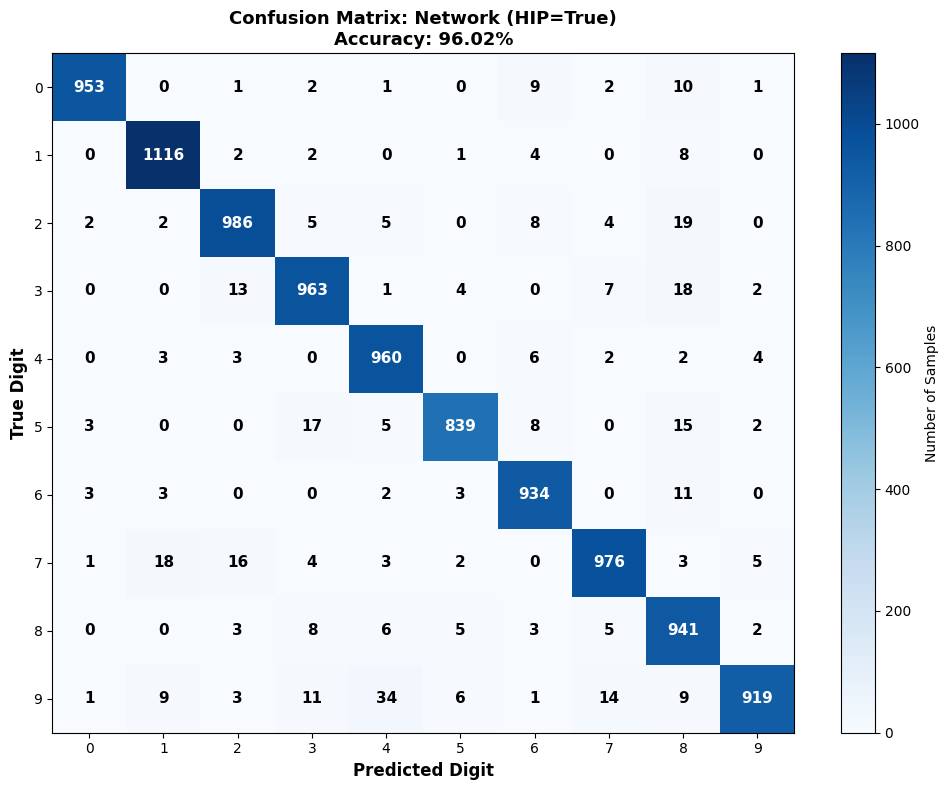


CONFUSION MATRIX ANALYSIS
Total Samples: 9984
Correct Predictions: 9587
Incorrect Predictions: 397
Overall Accuracy: 96.02%



In [24]:
plot_confusion_matrix(test_results, name=f"Network (HIP={HIP})")

### Evaluation of temporal spiking patterns on test samples
We used **raster plots** to show the spikes of each neuron over time, to compare activity patterns. <br>
We used **population plots** to show the average activity over time (across all neurons in a layer), to identify general layer activity. This can help to identify bursts or quiet phases.



In [25]:
def plot_sparsity_raster_with_hip(test_results, hip_target_rates=None, name="Network", sample_idx=0, num_hidden_show=150):
    """
    Plot raster diagrams with marginal firing rate histograms and HIP target lines.
    Shows activity for a single sample over timesteps.

    test_results: Dictionary from test_model()
    hip_target_rates: list [hidden_target, output_target] (e.g., [0.05, 0.05])
    sample_idx: Which sample to visualize (default: 0, first sample)
    """

    output_spikes = test_results['output_spikes']  # [samples, timesteps, 10]
    hidden_spikes = test_results['hidden_spikes']  # [samples, timesteps, num_hidden]

    # Extract single sample
    hidden_sample = hidden_spikes[sample_idx, :, :]  # [timesteps, num_hidden]
    output_sample = output_spikes[sample_idx, :, :]  # [timesteps, num_outputs]

    # ============ HIDDEN LAYER JOINT PLOT ============
    print(f"Generating Hidden Layer visualization (Sample {sample_idx})...")

    fig_h = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs_h = fig_h.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                             hspace=0.05, wspace=0.05)

    num_neurons_show = min(num_hidden_show, hidden_sample.shape[1])
    num_timesteps = hidden_sample.shape[0]

    # Prepare data for raster (single sample)
    sample_hidden_subset = hidden_sample[:, :num_neurons_show]

    # Raster plot (bottom-left)
    ax_raster_h = fig_h.add_subplot(gs_h[1, 0])

    spike_times, neuron_ids = torch.where(sample_hidden_subset > 0)

    ax_raster_h.scatter(spike_times.numpy(), neuron_ids.numpy(),
                       marker='|', s=20, alpha=0.7, color='darkblue')
    ax_raster_h.set_xlabel('Timestep', fontsize=11, fontweight='bold')
    ax_raster_h.set_ylabel('Neuron ID', fontsize=11, fontweight='bold')
    ax_raster_h.set_title(f'Raster Plot (First {num_neurons_show} neurons)',
                         fontsize=12, fontweight='bold')
    ax_raster_h.grid(True, alpha=0.1)
    ax_raster_h.set_xlim([-0.5, num_timesteps - 0.5])
    ax_raster_h.set_xticks(range(0, num_timesteps, 5))

    # Firing rate over timesteps (top-left)
    ax_activity_h = fig_h.add_subplot(gs_h[0, 0], sharex=ax_raster_h)

    # Firing rate for each timestep (across neurons)
    firing_rate_per_timestep_h = sample_hidden_subset.mean(dim=1) * 100

    ax_activity_h.plot(range(num_timesteps), firing_rate_per_timestep_h.numpy(),
                      color='steelblue', linewidth=2.5, marker='o', markersize=4)
    ax_activity_h.fill_between(range(num_timesteps), firing_rate_per_timestep_h.numpy(),
                              alpha=0.3, color='steelblue')

    # Add HIP target line
    if hip_target_rates and len(hip_target_rates) > 0:
        target = hip_target_rates[0] * 100
        ax_activity_h.axhline(target, color='red', linestyle='--', linewidth=2.5,
                             label=f'HIP Target: {target:.1f}%', alpha=0.8)
        ax_activity_h.legend(loc='upper right', fontsize=10)

    ax_activity_h.set_ylabel('Firing Rate (%)', fontsize=11, fontweight='bold')
    ax_activity_h.set_title('Firing Rate Over Timesteps', fontsize=11, fontweight='bold')
    ax_activity_h.grid(True, alpha=0.2, axis='y')
    ax_activity_h.tick_params(labelbottom=False)
    ax_activity_h.set_ylim([0, max(firing_rate_per_timestep_h) * 1.2])

    # Per-neuron firing rates (right side) - average across timesteps
    ax_firing_h = fig_h.add_subplot(gs_h[1, 1], sharey=ax_raster_h)

    neuron_firing_h = sample_hidden_subset.mean(dim=0) * 100

    ax_firing_h.barh(range(num_neurons_show), neuron_firing_h.numpy(),
                    color='steelblue', alpha=0.6, height=0.8)

    # Add HIP target line
    if hip_target_rates and len(hip_target_rates) > 0:
        target = hip_target_rates[0] * 100
        ax_firing_h.axvline(target, color='red', linestyle='--', linewidth=2.5,
                           label=f'Target: {target:.1f}%', alpha=0.8)
        ax_firing_h.legend(loc='lower right', fontsize=9)

    ax_firing_h.set_xlabel('Firing Rate (%)', fontsize=11, fontweight='bold')
    ax_firing_h.tick_params(labelleft=False)
    ax_firing_h.grid(True, alpha=0.2, axis='x')
    ax_firing_h.set_xlim([0, max(neuron_firing_h) * 1.2])

    plt.show()

    # ============ OUTPUT LAYER JOINT PLOT ============
    print("Generating Output Layer visualization...")

    fig_o = plt.figure(figsize=(12, 8), constrained_layout=True)
    gs_o = fig_o.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[1, 4],
                             hspace=0.05, wspace=0.05)

    num_timesteps_o = output_sample.shape[0]

    # Raster plot (bottom-left)
    ax_raster_o = fig_o.add_subplot(gs_o[1, 0])

    spike_times_o, neuron_ids_o = torch.where(output_sample > 0)

    ax_raster_o.scatter(spike_times_o.numpy(), neuron_ids_o.numpy(),
                       marker='|', s=100, alpha=0.8, color='green')
    ax_raster_o.set_xlabel('Timestep', fontsize=11, fontweight='bold')
    ax_raster_o.set_ylabel('Output Neuron (Digit)', fontsize=11, fontweight='bold')
    ax_raster_o.set_title('Raster Plot', fontsize=12, fontweight='bold')
    ax_raster_o.set_yticks(range(10))
    ax_raster_o.grid(True, alpha=0.1)
    ax_raster_o.set_xlim([-0.5, num_timesteps_o - 0.5])
    ax_raster_o.set_xticks(range(0, num_timesteps_o, 5))

    # Firing rate over timesteps (top-left)
    ax_activity_o = fig_o.add_subplot(gs_o[0, 0], sharex=ax_raster_o)

    # Firing rate for each timestep (across output neurons)
    firing_rate_per_timestep_o = output_sample.mean(dim=1) * 100

    ax_activity_o.plot(range(num_timesteps_o), firing_rate_per_timestep_o.numpy(),
                      color='green', linewidth=2.5, marker='o', markersize=5)
    ax_activity_o.fill_between(range(num_timesteps_o), firing_rate_per_timestep_o.numpy(),
                              alpha=0.3, color='green')

    # Add HIP target line
    if hip_target_rates and len(hip_target_rates) > 1:
        target = hip_target_rates[1] * 100
        ax_activity_o.axhline(target, color='red', linestyle='--', linewidth=2.5,
                             label=f'HIP Target: {target:.1f}%', alpha=0.8)
        ax_activity_o.legend(loc='upper right', fontsize=10)

    ax_activity_o.set_ylabel('Firing Rate (%)', fontsize=11, fontweight='bold')
    ax_activity_o.set_title('Firing Rate Over Timesteps', fontsize=11, fontweight='bold')
    ax_activity_o.grid(True, alpha=0.2, axis='y')
    ax_activity_o.tick_params(labelbottom=False)
    ax_activity_o.set_ylim([0, max(firing_rate_per_timestep_o) * 1.2])

    # Per-neuron firing rates (right side) - average across timesteps
    ax_firing_o = fig_o.add_subplot(gs_o[1, 1], sharey=ax_raster_o)

    neuron_firing_o = output_sample.mean(dim=0) * 100

    colors_output = ['green' if rate > 0 else 'lightgray' for rate in neuron_firing_o]
    ax_firing_o.barh(range(10), neuron_firing_o.numpy(),
                    color=colors_output, alpha=0.7, edgecolor='black', linewidth=1.5)

    # Add HIP target line
    if hip_target_rates and len(hip_target_rates) > 1:
        target = hip_target_rates[1] * 100
        ax_firing_o.axvline(target, color='red', linestyle='--', linewidth=2.5,
                           label=f'Target: {target:.1f}%', alpha=0.8)
        ax_firing_o.legend(loc='lower right', fontsize=9)

    ax_firing_o.set_xlabel('Firing Rate (%)', fontsize=11, fontweight='bold')
    ax_firing_o.tick_params(labelleft=False)
    ax_firing_o.grid(True, alpha=0.2, axis='x')
    ax_firing_o.set_xlim([0, max(neuron_firing_o) * 1.2])

    # Add value labels on output firing rates
    for i, rate in enumerate(neuron_firing_o):
        ax_firing_o.text(rate + 0.5, i, f'{rate:.1f}%', va='center', fontsize=9)

    plt.savefig("Raster.png")
    plt.show()

    # === HIP ADHERENCE ANALYSIS ===
    if hip_target_rates:
        print("\n" + "="*70)
        print(f"HIP TARGET ADHERENCE (Sample {sample_idx})")
        print("="*70)

        # Hidden layer
        target_h = hip_target_rates[0]
        firing_h = hidden_sample.mean(dim=0)
        within_h = ((firing_h > target_h * 0.8) & (firing_h < target_h * 1.2)).float().mean().item() * 100
        above_h = (firing_h > target_h * 1.2).float().mean().item() * 100
        below_h = (firing_h < target_h * 0.8).float().mean().item() * 100

        print(f"\nHIDDEN LAYER (Target: {target_h*100:.1f}%):")
        print(f"  Within ±20%:  {within_h:.1f}%")
        print(f"  Above target: {above_h:.1f}%")
        print(f"  Below target: {below_h:.1f}%")
        print(f"  Mean firing:  {firing_h.mean()*100:.2f}%")

        # Output layer
        if len(hip_target_rates) > 1:
            target_o = hip_target_rates[1]
            firing_o = output_sample.mean(dim=0)
            within_o = ((firing_o > target_o * 0.8) & (firing_o < target_o * 1.2)).float().mean().item() * 100
            above_o = (firing_o > target_o * 1.2).float().mean().item() * 100
            below_o = (firing_o < target_o * 0.8).float().mean().item() * 100

            print(f"\nOUTPUT LAYER (Target: {target_o*100:.1f}%):")
            print(f"  Within ±20%:  {within_o:.1f}%")
            print(f"  Above target: {above_o:.1f}%")
            print(f"  Below target: {below_o:.1f}%")
            print(f"  Mean firing:  {firing_o.mean()*100:.2f}%")

        print("="*70 + "\n")

Generating Hidden Layer visualization (Sample 2)...


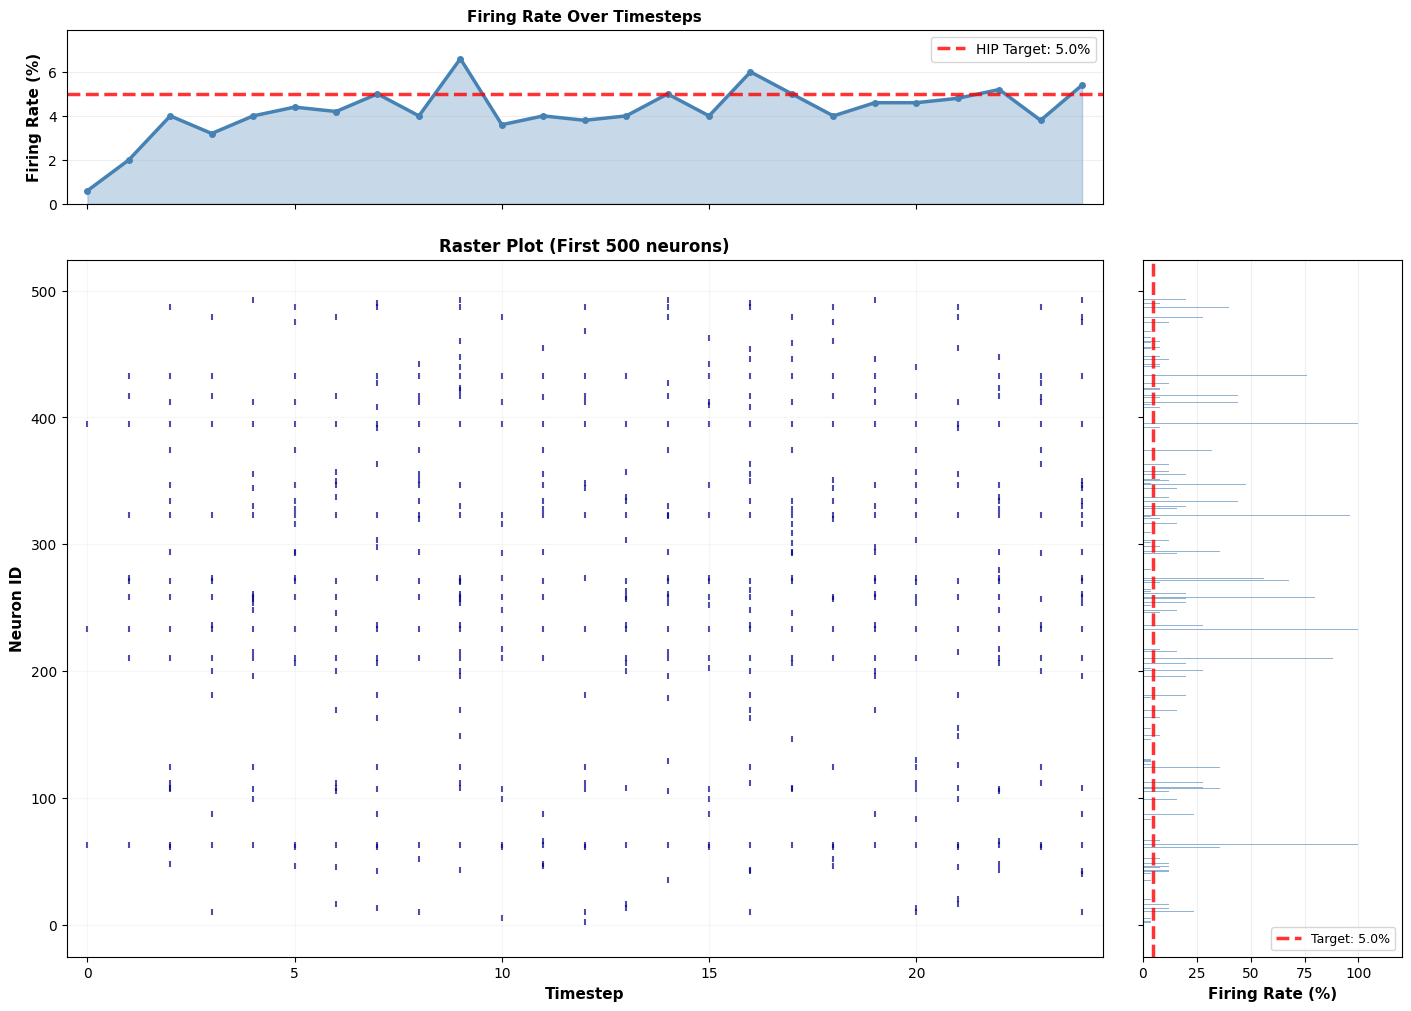

Generating Output Layer visualization...


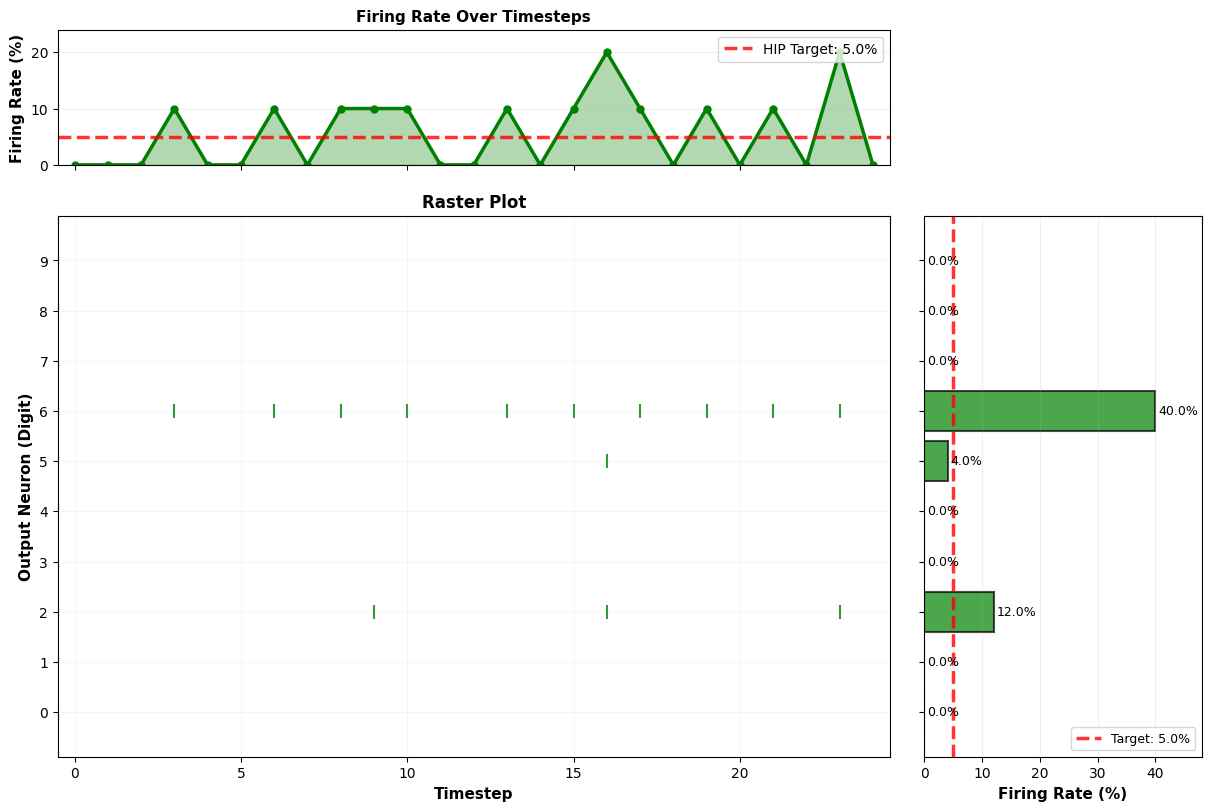


HIP TARGET ADHERENCE (Sample 2)

HIDDEN LAYER (Target: 5.0%):
  Within ±20%:  0.0%
  Above target: 16.0%
  Below target: 79.4%
  Mean firing:  3.68%

OUTPUT LAYER (Target: 5.0%):
  Within ±20%:  0.0%
  Above target: 20.0%
  Below target: 70.0%
  Mean firing:  5.60%



In [26]:
if HIP:
    hip_targets = target_rates  # From your training parameters
else:
    hip_targets = None

plot_sparsity_raster_with_hip(test_results,
                              hip_target_rates=hip_targets,
                              name=f"Network (HIP={HIP})",
                              sample_idx=2,
                              num_hidden_show=500)

### Evaluation - Generalizability of metric scores
The following plots compute the mean and variance of metric scores over all three random states. They can be used for generalizability analysis. <br>

Overall, we found the the variability between random states is small.

In [27]:
def parse_hip_csv(filepath):
    """Parse the entire CSV into a dataframe."""
    df = pd.read_csv(filepath)
    return df

def prepare_plot_data(df):
    """Extract and restructure data for plotting."""

    data = {
        'Configuration': [],
        'Target Firing Rate (%)': [],
        'Accuracy (%)': [],
        'Precision (%)': [],
        'Recall (%)': [],
        'F1-Score (%)': [],
        'Hidden Sparsity (%)': [],
        'Output Sparsity (%)': [],
        'Dead Neurons (hidden)': [],
        'Saturated Neurons (hidden)': []
    }

    current_config = None

    for idx, row in df.iterrows():
        first_col = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""

        # Check if this is a configuration header
        if '=' in first_col and not first_col.startswith('seed') and not first_col.startswith('Target'):
            current_config = first_col.strip('"')
            continue

        # Assign configuration for baseline 'seed' rows
        if first_col.startswith('seed'):
            current_config = 'Hidden = Leaky, Out = Leaky'

        # Skip header rows
        if 'Accuracy' in first_col or 'Target Firing Rate' in first_col:
            continue

        # Skip empty rows
        if pd.isna(row.iloc[0]) or first_col == '':
            continue

        # Determine if this is a seed or target firing rate
        target_rate = None
        if first_col.startswith('seed'):
            target_rate = 0  # Baseline seeds assigned to 0%
        elif '%' in first_col:
            try:
                target_rate = int(first_col.rstrip('%'))
            except ValueError:
                continue
        else:
            continue

        if target_rate is None: # Skip if target_rate couldn't be determined
            continue

        # Extract all metrics
        try:
            row_data = {
                'Configuration': current_config,
                'Target Firing Rate (%)': target_rate,
                'Accuracy (%)': float(str(row.iloc[1]).rstrip('%')),
                'Precision (%)': float(str(row.iloc[2]).rstrip('%')),
                'Recall (%)': float(str(row.iloc[3]).rstrip('%')),
                'F1-Score (%)': float(str(row.iloc[4]).rstrip('%')),
                'Hidden Sparsity (%)': float(str(row.iloc[5]).rstrip('%')),
                'Output Sparsity (%)': float(str(row.iloc[6]).rstrip('%')),
                'Dead Neurons (hidden)': int(row.iloc[7]),
                'Saturated Neurons (hidden)': int(row.iloc[8])
            }

            # Ensure the config is not None for data points
            if row_data['Configuration'] is None:
                continue

            for key, value in row_data.items():
                data[key].append(value)
        except (ValueError, TypeError):
            continue

    plot_df = pd.DataFrame(data)
    return plot_df

def plot_metric(plot_df, metric='Accuracy (%)', output_path=None):
    """
    Plot any metric against target firing rate with 95% CI.
    """

    fig, ax = plt.subplots(figsize=(11, 6))

    # Define colors with explicit z-order control
    palette = {
        'Hidden = Leaky, Out = Leaky': 'gray',
        'Hidden = LIF-HIP, Out = Leaky': 'steelblue',
        'Hidden = LIF-HIP, Out = LIF-HIP': 'coral'
    }

    # Separate baseline data from HIP data
    baseline_config_name = 'Hidden = Leaky, Out = Leaky'
    baseline_data = plot_df[(plot_df['Configuration'] == baseline_config_name) &
                            (plot_df['Target Firing Rate (%)'] == 0)]

    # Calculate baseline mean and CI
    baseline_mean = baseline_data[metric].mean()
    baseline_ci = baseline_data[metric].std() * 1.96 / np.sqrt(len(baseline_data)) if len(baseline_data) > 1 else 0

    # Plot baseline as horizontal line with shaded CI region
    ax.axhline(y=baseline_mean, color='gray', linestyle='--', linewidth=2.5,
               label=baseline_config_name, zorder=1)

    # Filter out baseline for lineplot
    plot_df_hip = plot_df[plot_df['Configuration'] != baseline_config_name].copy()

    # Ensure only the HIP configurations are in the hue_order for sns.lineplot
    hip_configs = [c for c in palette if c != baseline_config_name]
    ordered_hip_configs = [config for config in hip_configs if config in plot_df_hip['Configuration'].unique()]

    # Plot with seaborn for HIP configurations
    if not plot_df_hip.empty:
        sns.lineplot(data=plot_df_hip, x='Target Firing Rate (%)', y=metric,
                     hue='Configuration', style='Configuration',
                     markers=True, markersize=9, linewidth=2.5, dashes=False,
                     errorbar=('ci', 95),
                     palette={k: v for k, v in palette.items() if k != baseline_config_name},
                     hue_order=ordered_hip_configs,
                     ax=ax)
        ax.set_xlim([-0.5, 15.5])

    # add the baseline CI shading after plotting
    if len(baseline_data) > 1:
        xlim = ax.get_xlim()
        ax.fill_between([xlim[0], xlim[1]], baseline_mean - baseline_ci, baseline_mean + baseline_ci,
                         alpha=0.15, color='gray', zorder=0)

    ax.set_title(f'SNN {metric} vs. Target Firing Rate',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Target Firing Rate (%)', fontsize=12, fontweight='bold')
    ax.set_xticks([0, 5, 10, 15])
    # Dynamically set y-limits based on the metric and data, but keep it reasonable
    min_val = plot_df[metric].min() * 0.95 if plot_df[metric].min() > 0 else plot_df[metric].min() * 1.05
    max_val = plot_df[metric].max() * 1.05

    #set 100% as maximum for all % based values
    if '%' in metric:
      max_val = min(max_val, 100)
    ax.set_ylim([min_val, max_val])

    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='best', fontsize=11, framealpha=0.95)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Plot saved to {output_path}")
    plt.show()

To plot the results, please modify the path to the csv file.

Prepared data:
Configuration
Hidden = LIF-HIP, Out = LIF-HIP    [0, 5, 10, 15]
Hidden = LIF-HIP, Out = Leaky      [0, 5, 10, 15]
Hidden = Leaky, Out = Leaky                   [0]
Name: Target Firing Rate (%), dtype: object
✓ Plot saved to accuracy_comparison.png


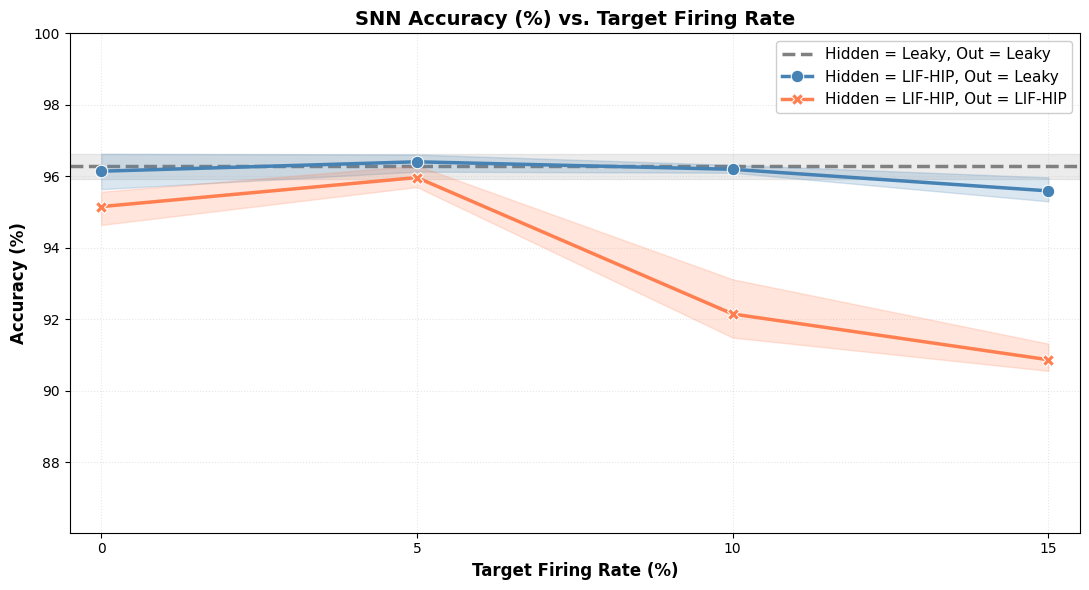

✓ Plot saved to f1_comparison.png


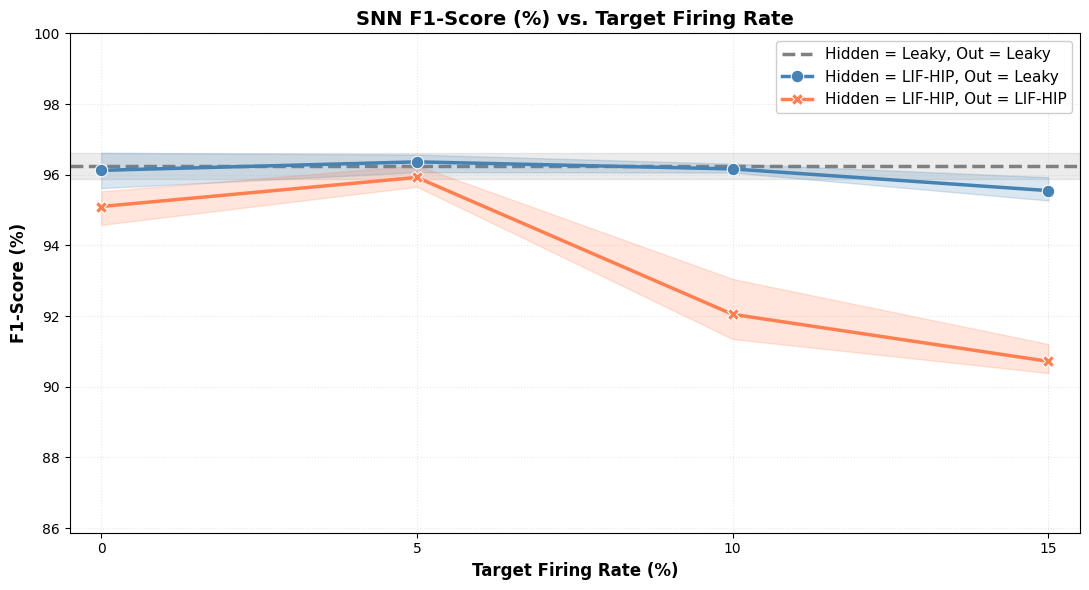

✓ Plot saved to sparsity_comparison.png


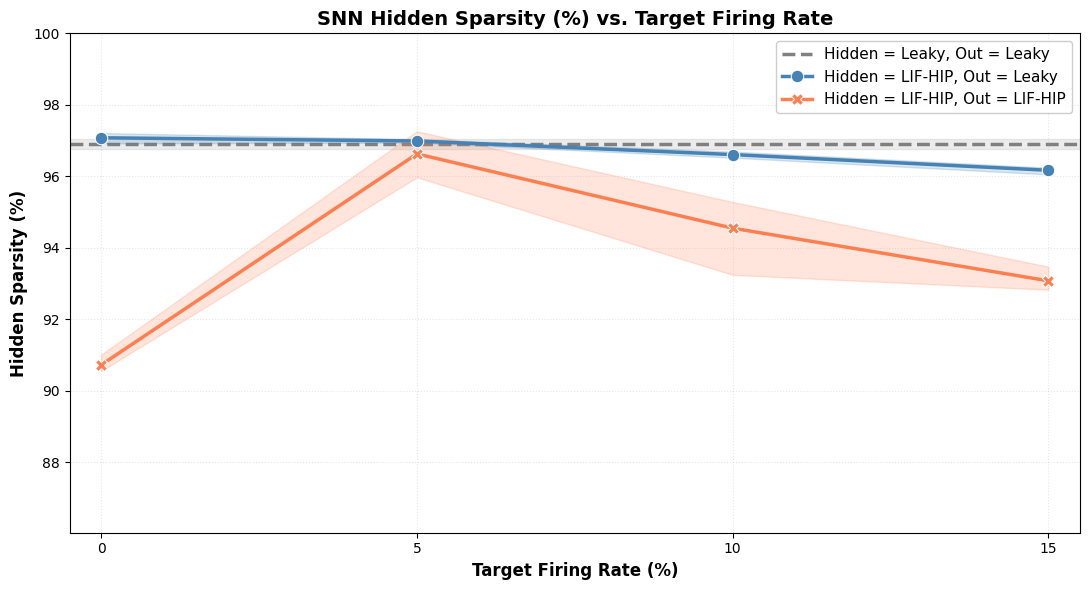

✓ Plot saved to sparsity_comparison.png


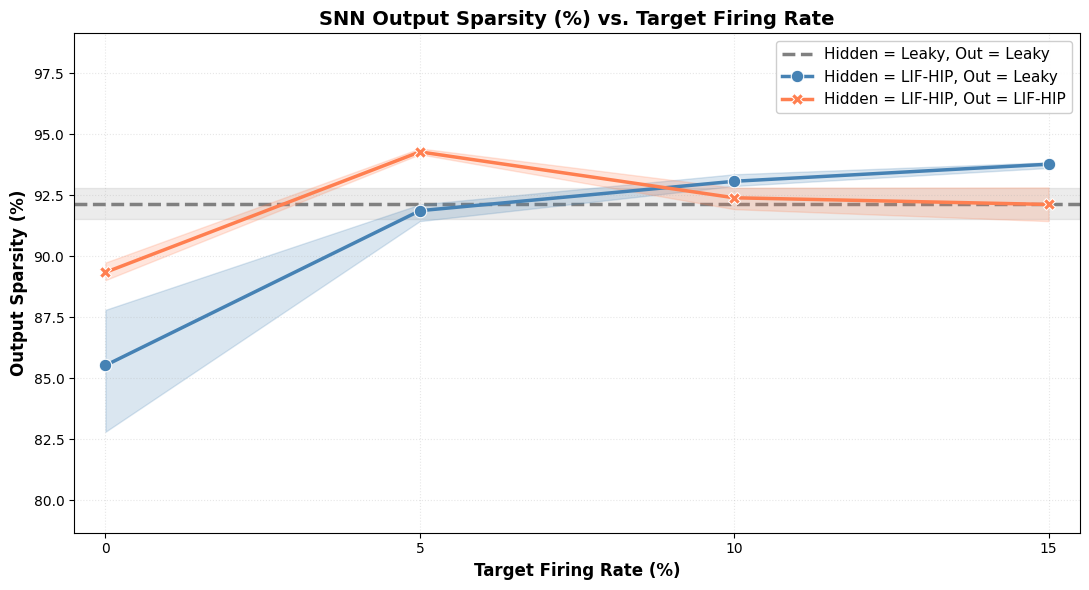

✓ Plot saved to dead_neurons_comparison.png


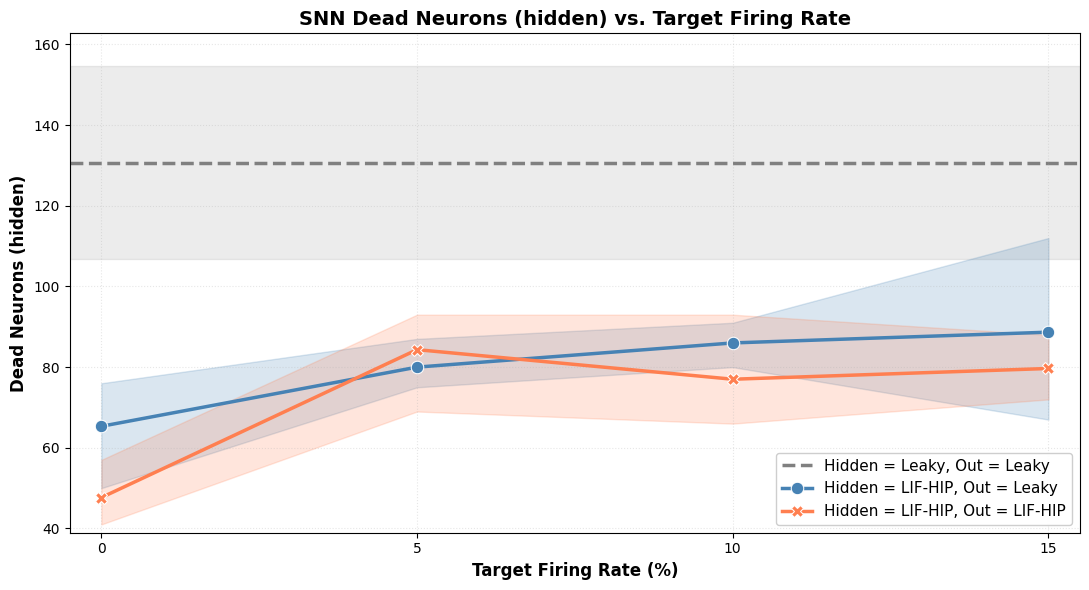

In [30]:
# Step 1: Parse entire CSV
df_raw = parse_hip_csv('./SNN_data.csv')

# Step 2: Prepare data for plotting
plot_df = prepare_plot_data(df_raw)
print("Prepared data:")
print(plot_df.groupby('Configuration')['Target Firing Rate (%)'].unique())

# Step 3: Plot different metrics
plot_metric(plot_df, metric='Accuracy (%)', output_path='accuracy_comparison.png')
plot_metric(plot_df, metric='F1-Score (%)', output_path='f1_comparison.png')
plot_metric(plot_df, metric='Hidden Sparsity (%)', output_path='sparsity_comparison.png')
plot_metric(plot_df, metric='Output Sparsity (%)', output_path='sparsity_comparison.png')
plot_metric(plot_df, metric='Dead Neurons (hidden)', output_path='dead_neurons_comparison.png')